In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import sys
import os

# Ensure src is in path
sys.path.append(os.path.abspath('..'))
from src.features import extract_features


In [2]:
# 1. Load data
print("Loading data...")
df = pd.read_pickle('../data/LSWMD.pkl')

# Clean failureType label
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if len(x)>0 and len(x[0])>0 else 'None')
df['failureType'] = df['failureType'].replace({'none': 'Normal'})

labeled_df = df[df['failureType'] != 'None'].copy()
print(f"Total labeled wafers: {len(labeled_df)}")


Loading data...


Total labeled wafers: 172950


In [3]:
# Precompute lot purity to pass into extract_features or handle post-extraction
def process_wafer(row):
    wafer_map = row.waferMap
    try:
        # Pass None to lot_df to avoid passing large dataframes to workers
        feats = extract_features(wafer_map, lot_df=None)
        feats['failureType'] = row.failureType
        feats['lotName'] = row.lotName if isinstance(row.lotName, str) else str(row.lotName)
        return feats
    except Exception as e:
        return None

print("Extracting features (using parallel processing)...")
results = Parallel(n_jobs=-1)(
    delayed(process_wafer)(row) for _, row in tqdm(labeled_df.iterrows(), total=len(labeled_df))
)

features_df = pd.DataFrame([r for r in results if r is not None])


Extracting features (using parallel processing)...


  0%|          | 0/172950 [00:00<?, ?it/s]

In [4]:
# 3. Handle lot_consistency efficiently
print("Calculating lot consistency...")
# Clean lotName just in case
features_df['lotName'] = features_df['lotName'].apply(lambda x: x if isinstance(x, str) else str(x))

# Group by lotName to find purity (max fraction of identical failureType)
lot_purity = features_df.groupby('lotName')['failureType'].apply(lambda x: x.value_counts().iloc[0] / len(x)).to_dict()

# Overwrite the lot_consistency column
features_df['lot_consistency'] = features_df['lotName'].map(lot_purity).fillna(0.5)

# Drop temporary lotName column
features_df = features_df.drop(columns=['lotName'])

# 4. Save to data/features_labeled.pkl
features_df.to_pickle('../data/features_labeled.pkl')
print(f"Saved features_labeled.pkl with shape {features_df.shape}")
print(f"Nulls: {features_df.isnull().sum().sum()}")


Calculating lot consistency...


Saved features_labeled.pkl with shape (172950, 29)
Nulls: 0


In [5]:
# 5. Summary stats
feature_cols = [c for c in features_df.columns if c != 'failureType']
summary_stats = features_df[feature_cols].agg(['mean', 'std']).T
print("Feature Summary Statistics:")
print(summary_stats)


Feature Summary Statistics:
                     mean       std
defect_ratio     0.117627  0.073514
radial_cdf_0     0.029142  0.022357
radial_cdf_1     0.075682  0.042280
radial_cdf_2     0.144853  0.062773
radial_cdf_3     0.236029  0.082921
radial_cdf_4     0.350684  0.097961
radial_cdf_5     0.507354  0.110601
radial_cdf_6     0.812412  0.076443
radial_cdf_7     0.997907  0.016132
radial_cdf_8     0.999828  0.003546
radial_cdf_9     0.999994  0.002405
edge_sector_0    0.000071  0.001938
edge_sector_1    0.000066  0.001256
edge_sector_2    0.000102  0.001703
edge_sector_3    0.000117  0.001934
edge_sector_4    0.000112  0.001841
edge_sector_5    0.000094  0.001682
edge_sector_6    0.000080  0.001516
edge_sector_7    0.000066  0.001348
edge_sector_std  0.000139  0.001394
cx              -0.003476  0.083861
cy               0.021302  0.085828
compactness      0.963441  0.034066
aspect_ratio     0.995763  0.145820
morans_i         0.086227  0.105670
n_clusters       6.618075  3.957569


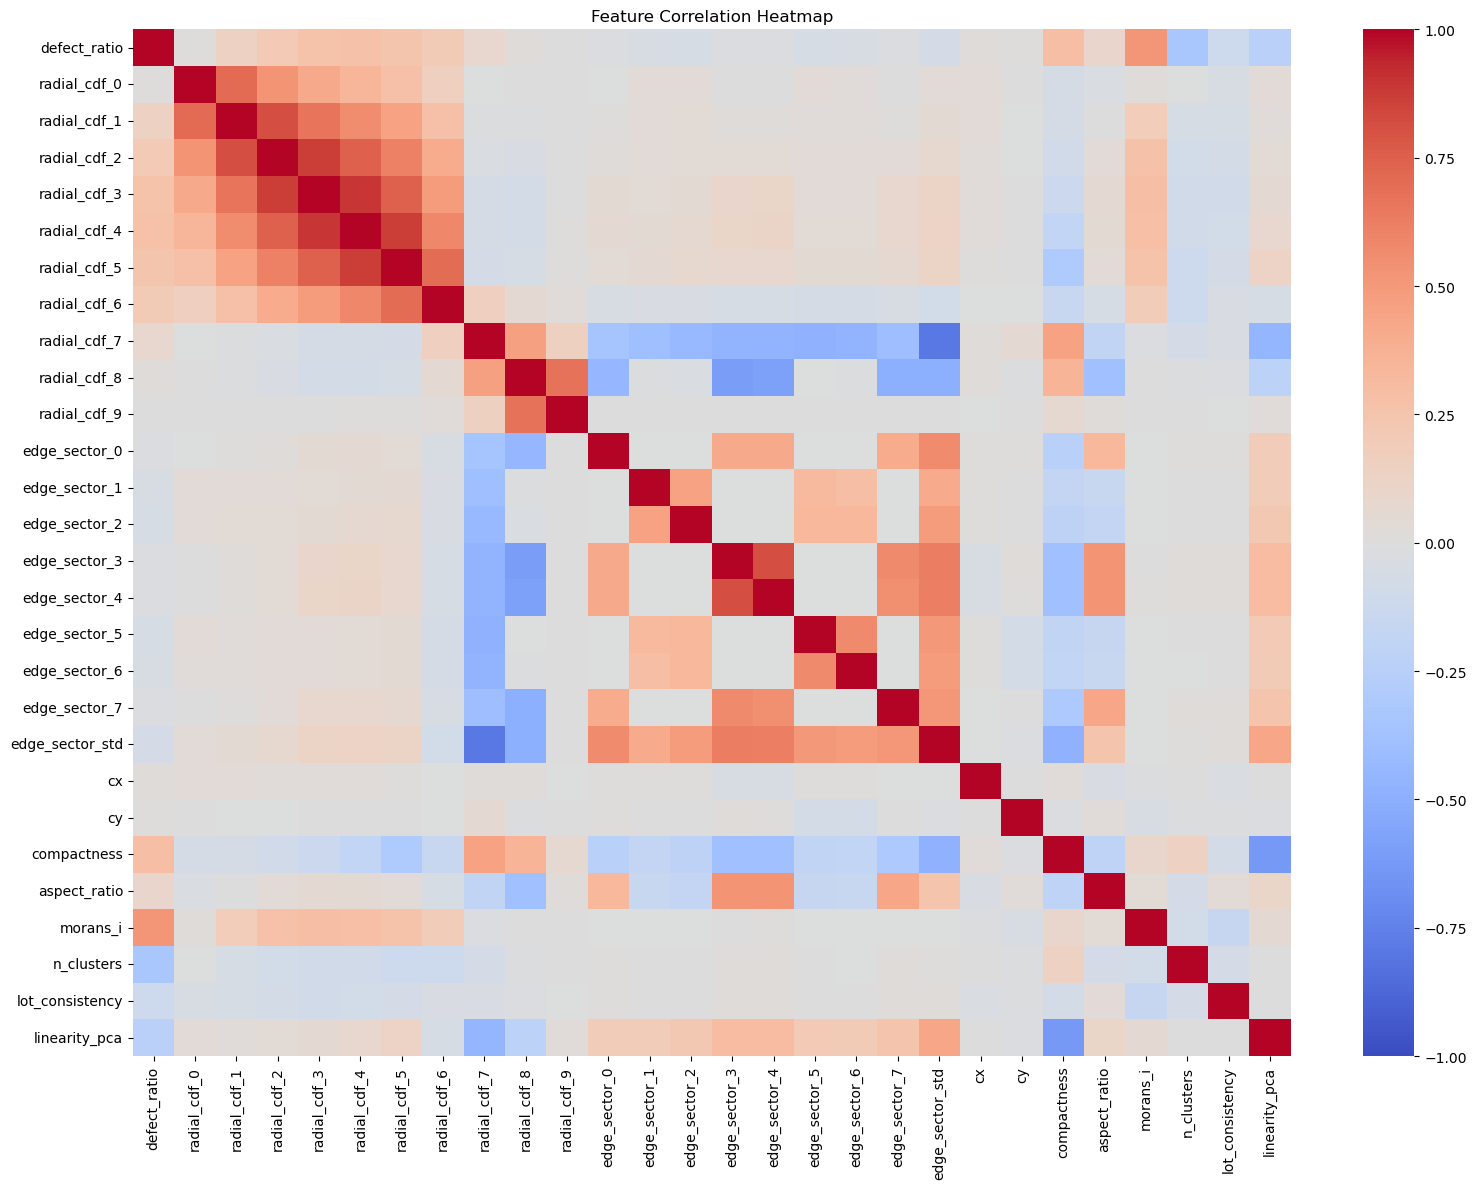

In [6]:
# 6. Correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = features_df[feature_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()

os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
